In [6]:
pip install matplotlib seaborn

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
ds = pd.read_excel("Cleaned_DecodeLabs.xlsx")
print(ds.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [9]:
print(ds.info())

print(ds.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [10]:
print("\nMEAN VALUES")
print(ds[["Quantity", "UnitPrice", "TotalPrice"]].mean())

print("\nMEDIAN VALUES")
print(ds[["Quantity", "UnitPrice", "TotalPrice"]].median())

print("\nMODE VALUES")

print(ds[["Quantity", "UnitPrice", "TotalPrice"]].mode())

print("\nCOUNT VALUES")
print(ds[["Quantity", "UnitPrice", "TotalPrice"]].count())


MEAN VALUES
Quantity         2.945833
UnitPrice      356.412750
TotalPrice    1053.968300
dtype: float64

MEDIAN VALUES
Quantity        3.000
UnitPrice     364.210
TotalPrice    823.615
dtype: float64

MODE VALUES
   Quantity  UnitPrice  TotalPrice
0       1.0     127.18      211.14
1       NaN     133.39      367.34
2       NaN     136.84      410.52
3       NaN     183.67      635.90
4       NaN     228.91     2517.36
5       NaN     466.42         NaN
6       NaN     629.34         NaN

COUNT VALUES
Quantity      1200
UnitPrice     1200
TotalPrice    1200
dtype: int64


In [11]:
print("\nMOST ORDERED PRODUCTS")

print(ds["Product"].value_counts().head(10))


MOST ORDERED PRODUCTS
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [12]:
print("\nPAYMENT METHOD DISTRIBUTION")

print(ds["PaymentMethod"].value_counts())


PAYMENT METHOD DISTRIBUTION
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [13]:
print("\nORDER STATUS DISTRIBUTION")

print(ds["OrderStatus"].value_counts())


ORDER STATUS DISTRIBUTION
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [14]:
Q1 = ds["TotalPrice"].quantile(0.25)
Q3 = ds["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ds[
    (ds["TotalPrice"] < lower_bound) |
    (ds["TotalPrice"] > upper_bound)
]

print("\nNUMBER OF OUTLIERS:")
print(len(outliers))


NUMBER OF OUTLIERS:
8


In [15]:
outliers[["OrderID", "Product", "TotalPrice"]].to_excel(
    "Outliers_Report.xlsx",
    index=False
)

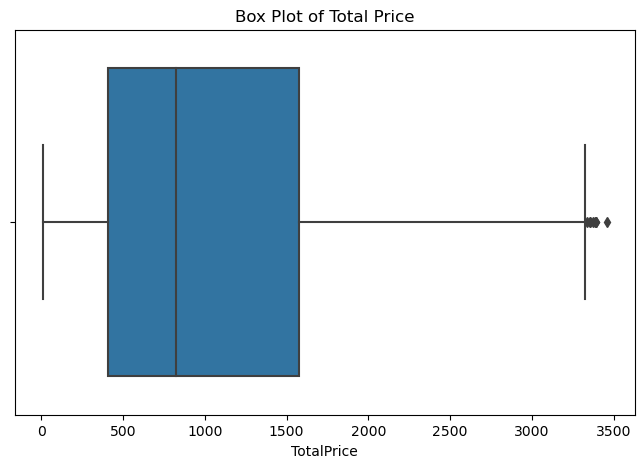

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=ds["TotalPrice"])

plt.title("Box Plot of Total Price")

plt.show()

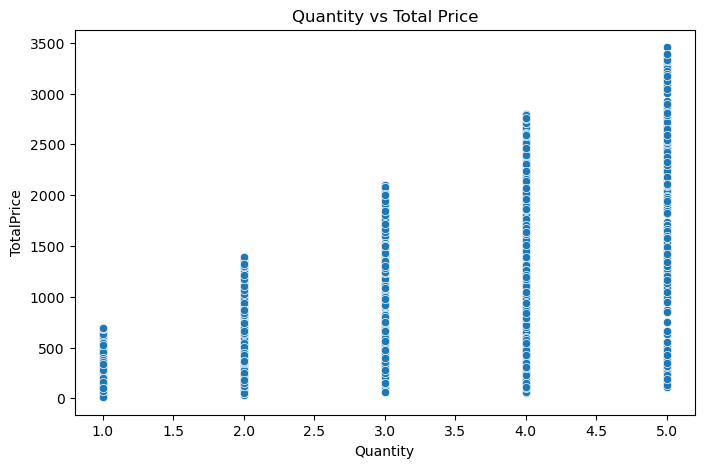

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=ds["Quantity"],
    y=ds["TotalPrice"]
)

plt.title("Quantity vs Total Price")

plt.show()

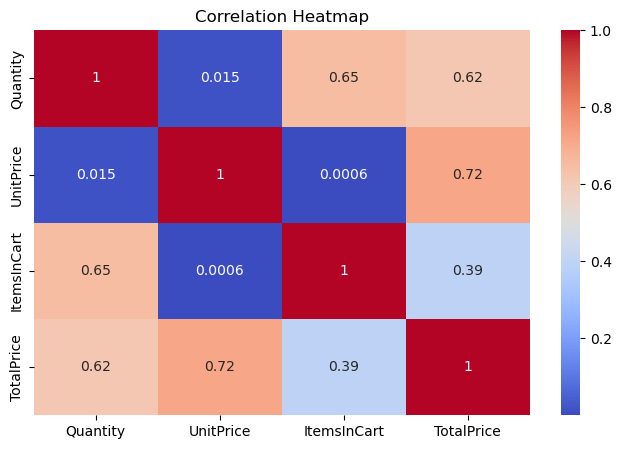

In [18]:
numeric_data = ds[[
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]]

correlation = numeric_data.corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

C:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


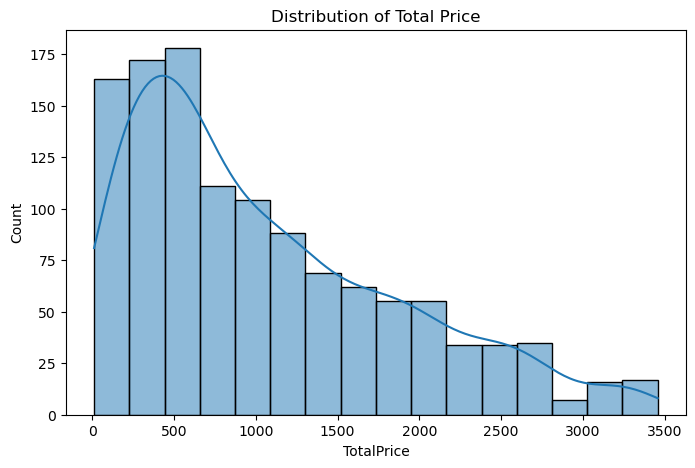

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    ds["TotalPrice"],
    kde=True
)

plt.title("Distribution of Total Price")

plt.show()

In [20]:
plt.savefig("boxplot_totalprice.png")

<Figure size 640x480 with 0 Axes>

In [21]:
plt.show()

In [22]:
plt.savefig("heatmap.png")

plt.show()

<Figure size 640x480 with 0 Axes>